### 코랩 사용법
- 기존 Jupyter Notebooks에서 Ctrl + M 추가해서 사용
- 마크다운 셀 변경 : Ctrl + M + M
- 코드 셀 변경 : Ctrl + M + Y
- 새로운 셀 추가 : Ctrl + M + B
- 셀 삭제 : Ctrl + M + D
- 셀 실행 후 다음 셀 이동 : Shift + Enter


### 딥러닝
- 딥러닝이란?
  - 인간의 신경망을 모방하여 학습하고 예측하는 기술
  - 대량의 데이터에서 복잡한 패턴, 규칙 등을 찾아내는 능력이 뛰어남
  - 인간의 뉴런 == 딥러닝 선형 모델(인공신경망)
  - **병렬적 다층 구조**로 이루어져 있음
  - 음성처리, 자연어 처리, 비전 영역 등에서 많이 사용되고 있음

### 머신러닝과 딥러닝의 차이점
- 머신러닝
  - 완성된 모델을 우리가 가져다가 사용하는 방법
  - 모델을 불러오기(완성된 객체) -> 모델 학습 -> 모델 예측 -> 모델 평가
- 딥러닝
  - 모델을 직접 구성하여 사용하는 방법
  - 모델 도구 불러와서 조립(우리가 직접 구성) -> 모델 학습 -> 모델 예측 -> 모델 평가
  - 평가가 안좋을 경우 다시 학습을 진행(우리가 설정한 epoch만큼)
  - epoch : 학습 횟수

### 퍼셉트론
- 사람의 뉴런을 모방한 방법으로 한개의 퍼셉트론은 선형함수와 활성화함수로 이루어져 있다.
- 퍼셉트론 : 선형함수(y=wx+b) + 활성화함수(activation)
- 활성화 함수(activation) : 사람처럼 판단하여 행동하도록 만든 함수
- 특정 자극(역치)이상의 값이 들어올 때 다음층으로 전달하도록 설정하는 함수

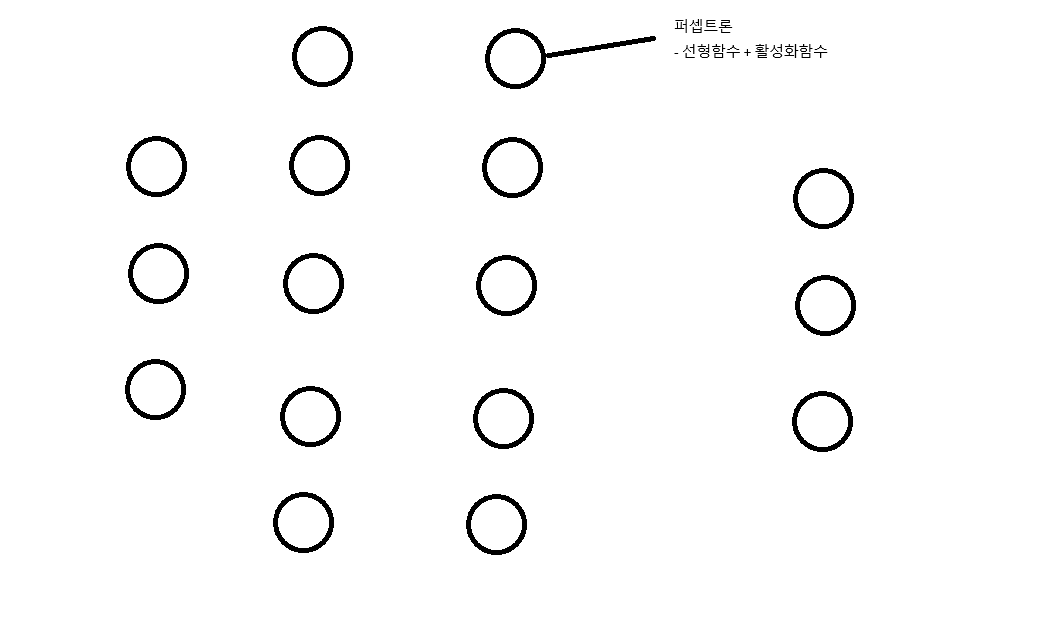

### 맛보기
- 딥러닝을 사용하기 위해서 tensorflow에서 제공하는 데이터셋으로 딥러닝 신경망 설계하기

### Tensorflow
- 딥러닝을 활용하기 위해 여러가지 도구를 불러올수 있도록 도와주는 거대 라이브러리

In [1]:
# 데이터를 다루기 위한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 데이터 불러오기
from sklearn.datasets import load_breast_cancer

In [3]:
# 데이터 로드(불러오기)
breast_cancer = load_breast_cancer()
# 문제데이터
X = breast_cancer['data']
# 정답데이터
y = breast_cancer.target

In [4]:
# 데이터 크기 확인
print(X.shape)
print(y.shape)

# 데이터의 개수 : 569개
# 데이터의 입력특성의 수(features) : 30개

(569, 30)
(569,)


In [5]:
# train, test 분리 진행
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3,
                                                    random_state = 5)

In [6]:
# 데이터 확인
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

# 반드시 체크 사항
# 1. 문제의 개수와 정답의 개수가 같은지 확인(X_train : y_train, X_test : y_test)
# 2. 학습용 데이터와 테스트용 데이터의 입력특성의 수 확인 (X_train : X_test)

(398, 30)
(171, 30)
(398,)
(171,)


### 딥러닝 신경망 설계
- 뼈대 : 여러개의 층을 설계할 수 있도록 하는 역활
- 입력층 : 데이터를 받아올 수 있도록 도와주는 층
- 중간층(은닉층) : 실제 계산(예측)이 일어나는 층
- 출력층 : 계산된 결과를 가지고 예측값을 출력하는 층

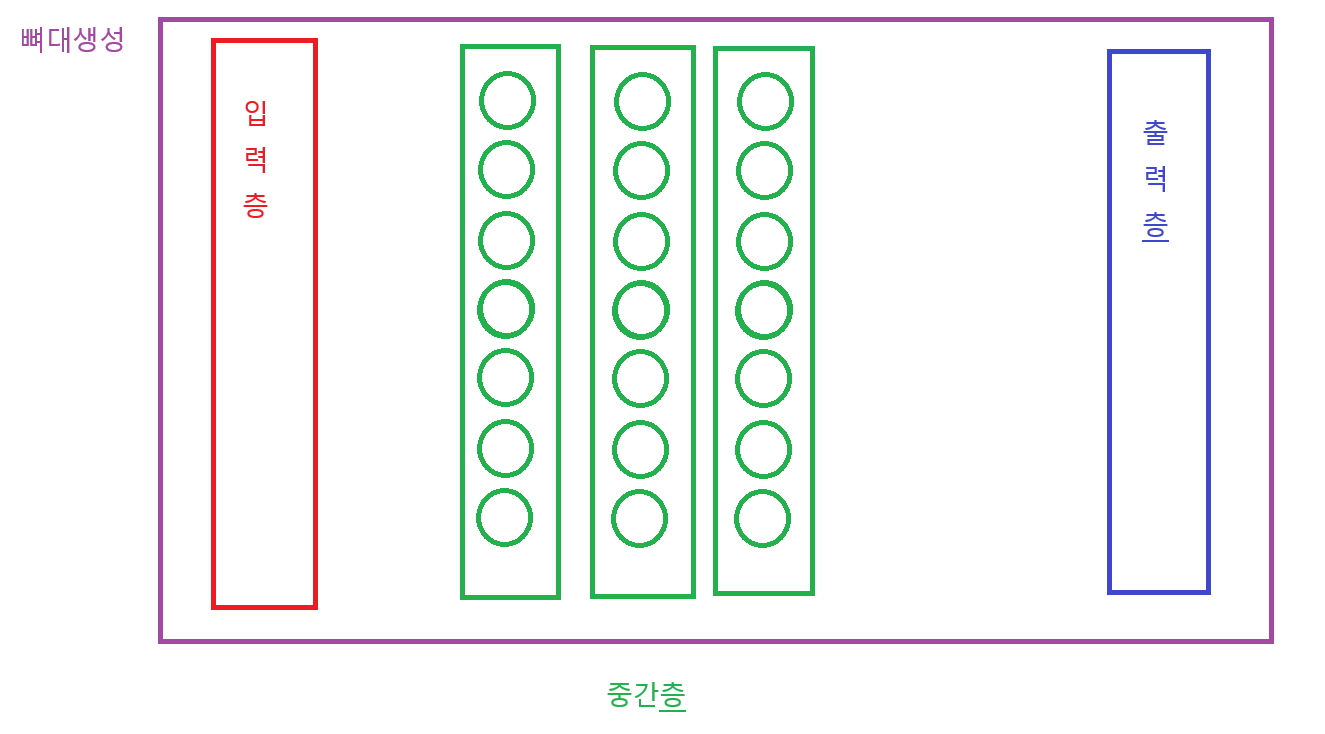

In [8]:
# 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense

# Sequential : 뼈대를 생성할 수 있도록 도와주는 도구
# InputLayer : 입력층을 쌓을 수 있도록 도와주는 도구 중에 하나
# Dense : 신경망 층을 쌓도록 도와주는 도구 (중간층, 출력층에 사용)

In [17]:
# 신경망 구조 설계
# 1. 뼈대생성
model = Sequential()

# 2. 입력층 쌓기
model.add(InputLayer(shape=(30,)))

# 3. 중간층 쌓기
model.add(Dense(units = 32, activation = 'sigmoid'))
# units : 퍼셉트론의 개수
# activation(활성화 함수) : 사람처럼 사고하도록 설정하는 함수
# 특정 이상의 값(역치)이 왔을때만 값을 넘겨주는 기능

# 4. 출력층 쌓기
model.add(Dense(units=1, activation = 'sigmoid'))
# 우리가 예측하고자 하는 정답의 종류가 암의 여부(True/False)의 이진분류이기 때문

# 출력층은 예측하고자 하는 데이터에 형태에 따라 다르게 사용
# 회귀 : units = 1 / activation = 'linear'
# 이진분류(정답의 종류가 2개인 경우) : units = 1 / activation = 'sigmoid'
# 다중분류(정답의 종류가 3개 이상인 경우) : units = 정답의 종류 / activation = 'softmax'

In [18]:
# 학습방법 및 평가방법 설정
# compile : 학습방법과 평가방법을 설정할 수 있도록 도와주는 기능
model.compile(
    # loss : 오차 계산 방법
    loss = 'binary_crossentropy',
    # optimizer : 최적화함수 (학습방법 설정) - 오차를 줄여나가는 방법 설정
    optimizer = 'SGD', # SGD : 경사하강법 사용
    # 평가지표 설정
    metrics = ['accuracy']
)
# loss 방법
# 회귀 : mean_squared_error
# 이진분류 : binary_crossentropy
# 다중분류 : catergorical_crossentropy

In [19]:
# 학습 진행
model.fit(X_train, y_train, validation_split = 0.2, epochs = 20)
# validation_split : 검증데이터의 비율
# epochs : 학습횟수

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6384 - loss: 0.6400 - val_accuracy: 0.5500 - val_loss: 0.6616
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.6238 - val_accuracy: 0.5500 - val_loss: 0.6926
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.6568 - val_accuracy: 0.5500 - val_loss: 0.6766
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.6178 - val_accuracy: 0.5500 - val_loss: 0.6597
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.5997 - val_accuracy: 0.5500 - val_loss: 0.6568
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.6535 - val_accuracy: 0.5500 - val_loss: 0.6940
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6384 - loss: 0.6569 - val_accuracy: 0.5500 - val_loss: 0.6977
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6384 - loss: 0.6554 - val_accuracy: 0.5500 - val_lo

### 결과 시각화

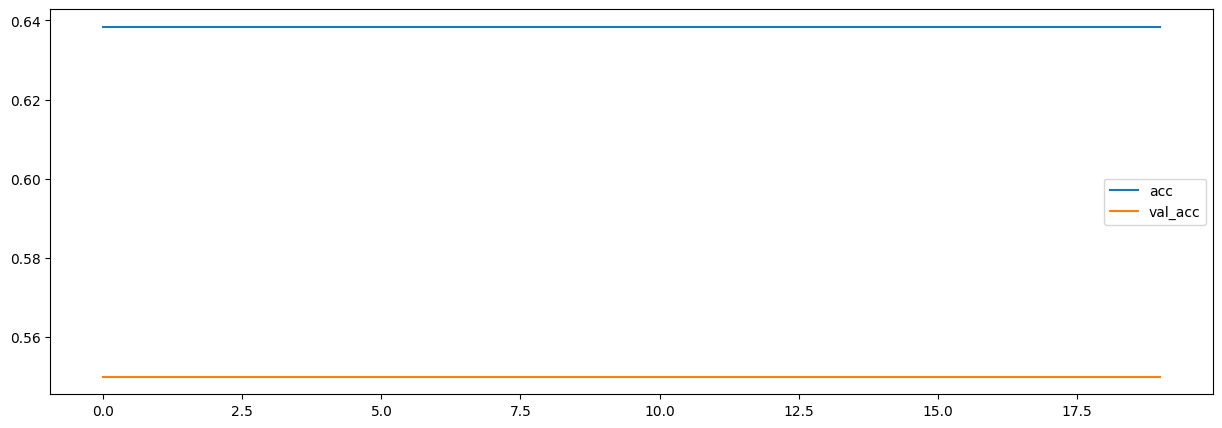

In [20]:
# 그래프의 크기 설정(도화지 크기)
plt.figure(figsize=(15,5))
# 학습한 결과 출력(정확도)
plt.plot(model.history.history['accuracy'], label='acc')
# 학습한 결과 출력(검증데이터의 정확도)
plt.plot(model.history.history['val_accuracy'], label='val_acc')
# 주석 설정
plt.legend()
# 그래프 출력
plt.show()

### MLP (Multi Layer Perceptron)
- 단층 퍼셉트론 층으로는 해결하지 못하는 문제를 해결하기 위해 여러개의 층으로 구성하여 만든 신경망 구조

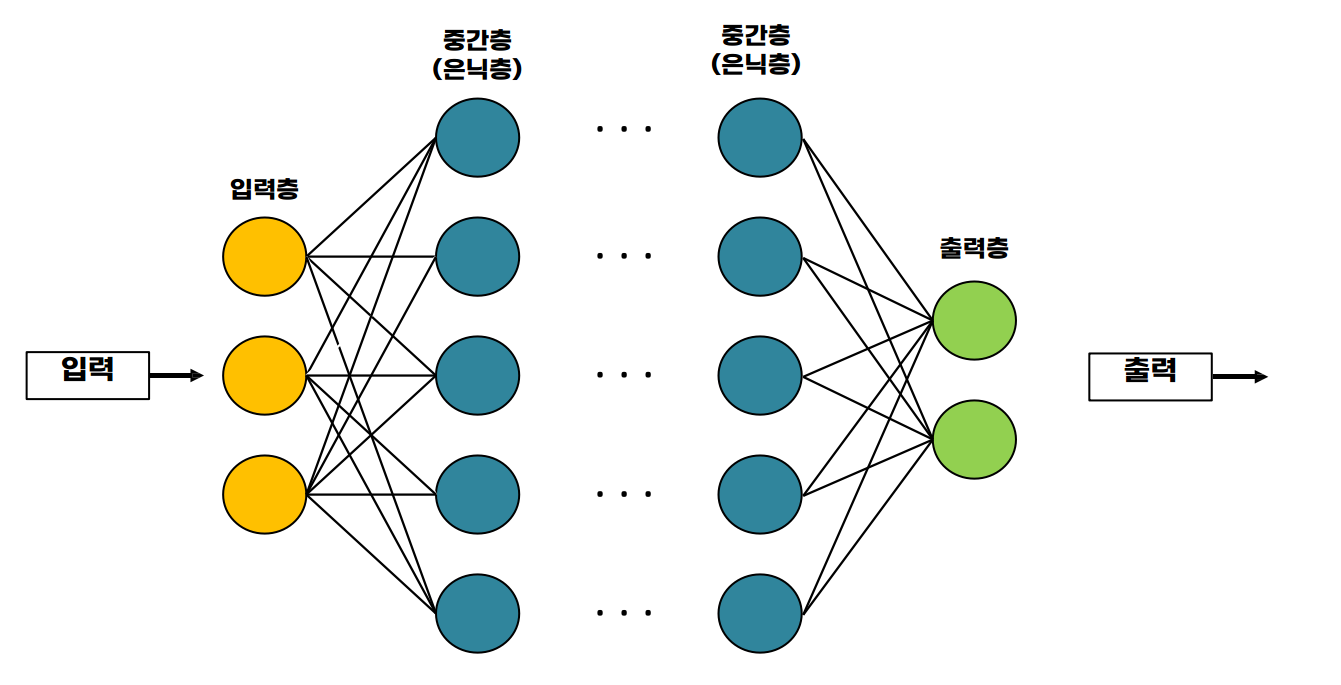

### 위의 데이터를 활영하여 여러개의 층을 가지고 있는 MLP층 설계하기

In [21]:
# MLP층 설계
# 신경망 설계
# 1. 뼈대 생성
model2 = Sequential()

# 입력층 쌓기
model2.add(InputLayer(shape=(30,))) # 입력 특성의 수에 따라 크기를 다르게 설정

# 여러개의 중간층 쌓기
model2.add(Dense(units = 32, activation = 'sigmoid'))
model2.add(Dense(units = 64, activation = 'sigmoid'))
model2.add(Dense(units = 32, activation = 'sigmoid'))

# 출력층 쌓기
# 이진분류이기 때문에 units = 1 / activation = sigmoid
model2.add(Dense(units = 1, activation = 'sigmoid'))

In [22]:
# 학습방법 및 평가방법 설정
model2.compile(
    loss = 'binary_crossentropy', # 이진분류 전용 오차 계산 함수
    optimizer = 'SGD',
    metrics = ['accuracy']
)

In [23]:
# 학습 진행
model2.fit(X_train, y_train, validation_split=0.2, epochs = 100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6384 - loss: 0.6758 - val_accuracy: 0.5500 - val_loss: 0.6853
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6384 - loss: 0.6641 - val_accuracy: 0.5500 - val_loss: 0.6854
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.6575 - val_accuracy: 0.5500 - val_loss: 0.6856
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6384 - loss: 0.6529 - val_accuracy: 0.5500 - val_loss: 0.6866
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6384 - loss: 0.6506 - val_accuracy: 0.5500 - val_loss: 0.6881
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6384 - loss: 0.6489 - val_accuracy: 0.5500 - val_loss: 0.6892
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.6478 - val_accuracy: 0.5500 - val_loss: 0.6900
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.6463 - val_accuracy: 0.550

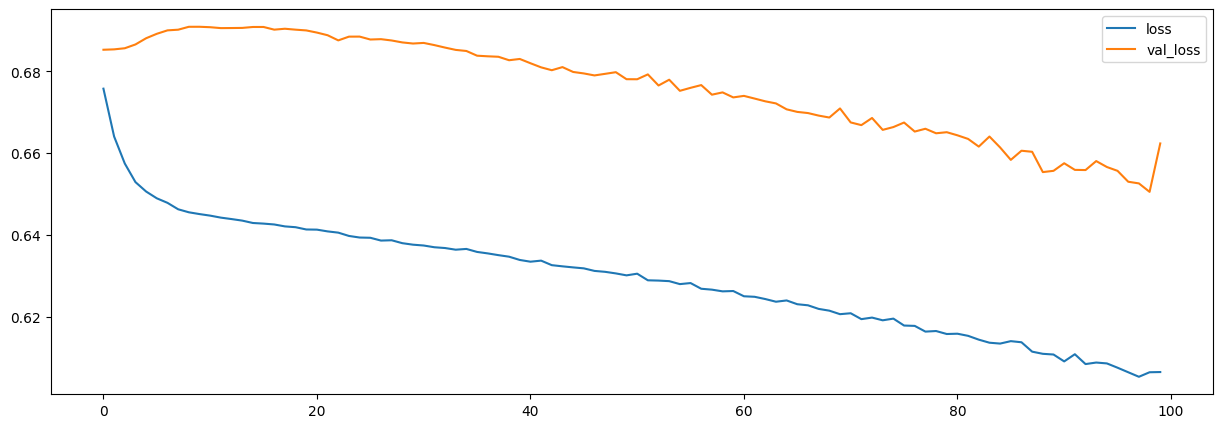

In [24]:
# 시각화 진행 (오차에 대해 시각화)
plt.figure(figsize=(15,5))
plt.plot(model2.history.history['loss'], label = 'loss')
plt.plot(model2.history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

### 결과 확인
- 오차가 줄어들면서 학습하고 있는것은 맞음
- 다만 특정값 이상 줄어들지 않고 정확도도 특정 수치 이상 올라가지 않는다.
- activation과 optimizer의 방법의 한계 때문인 것으로 판단이 됨

In [25]:
# 3번째 방법으로 신경망 설계
# 뼈대생성
model3 = Sequential()

# 입력층 쌓기
model3.add(InputLayer(shape=(30,)))

# 중간층 쌓기
model3.add(Dense(units = 32, activation = 'relu'))
model3.add(Dense(units = 64, activation = 'relu'))
model3.add(Dense(units = 32, activation = 'relu'))

# 출력층 쌓기
model3.add(Dense(units = 1, activation = 'sigmoid'))

In [26]:
# 학습방법 및 평가방법 설정
model3.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [27]:
# 학습 진행
model3.fit(X_train, y_train, validation_split=0.2, epochs = 100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6384 - loss: 47.8748 - val_accuracy: 0.4500 - val_loss: 2.5966
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3616 - loss: 10.1269 - val_accuracy: 0.4500 - val_loss: 4.9434
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5818 - loss: 2.9162 - val_accuracy: 0.7250 - val_loss: 1.1004
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6258 - loss: 1.0529 - val_accuracy: 0.8625 - val_loss: 0.3014
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8774 - loss: 0.5389 - val_accuracy: 0.8750 - val_loss: 0.3008
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8365 - loss: 0.4478 - val_accuracy: 0.8750 - val_loss: 0.3591
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9245 - loss: 0.3118 - val_accuracy: 0.8625 - val_loss: 0.2840
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9245 - loss: 0.2669 - val_accuracy: 0.8

### loss(오차값)에 대한 시각화 진행

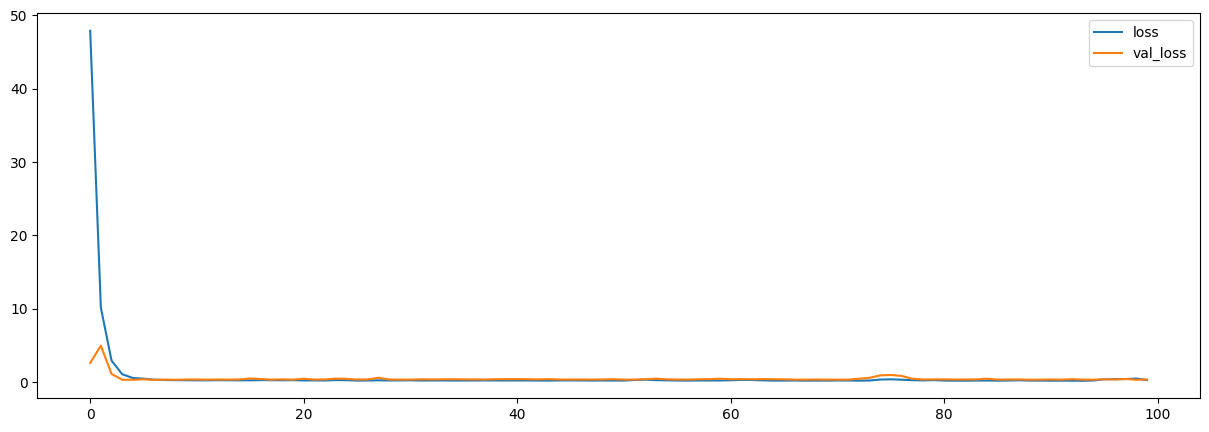

In [28]:
plt.figure(figsize=(15,5))
plt.plot(model3.history.history['loss'], label = 'loss')
plt.plot(model3.history.history['val_loss'], label = 'val_loss')
plt.legend()
plt.show()

### 정확도에 따른 성능 확인

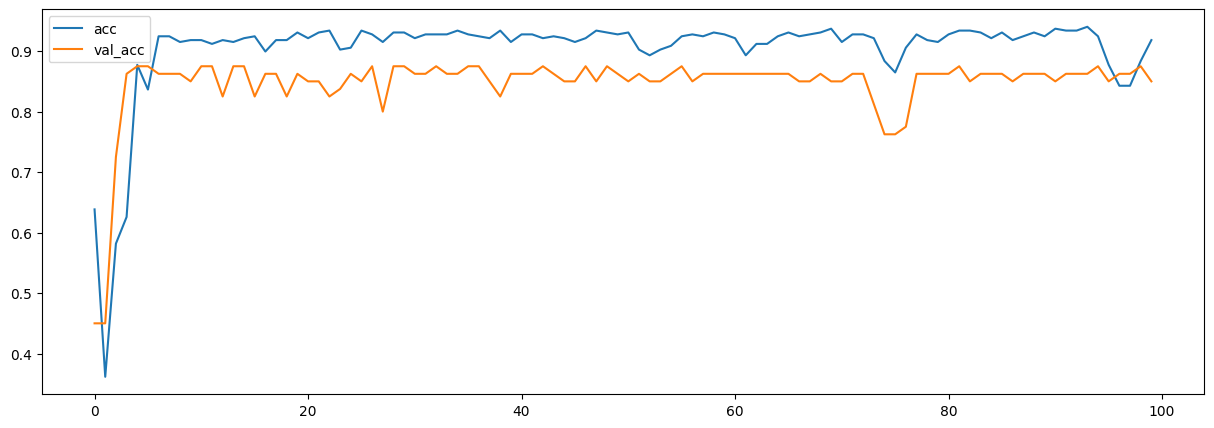

In [29]:
plt.figure(figsize=(15,5))
plt.plot(model3.history.history['accuracy'], label = 'acc')
plt.plot(model3.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### Sigmoid 함수
- 가장 초창기부터 사용된 활성화 함수
- 0~1사이의 값으로 결과를 출력
- 비선형 문제를 해결하기 위해 제안이 된 함수로 0또는 1의 값을 가지는 이진분류에서 사용이 됨
- 출력값이 단순하게 사용되기 때문에 해석하기 쉽다는 장점이 있음
- 기울기 손실(Vanishing Graident)가 일어나기 쉬워 입력데이터에 대해서 복잡한 데이터가 들어오거나 층이 깊어질 수록 기울기가 0에 가까워져 학습이 잘 이루어지지 않는 문제가 발생

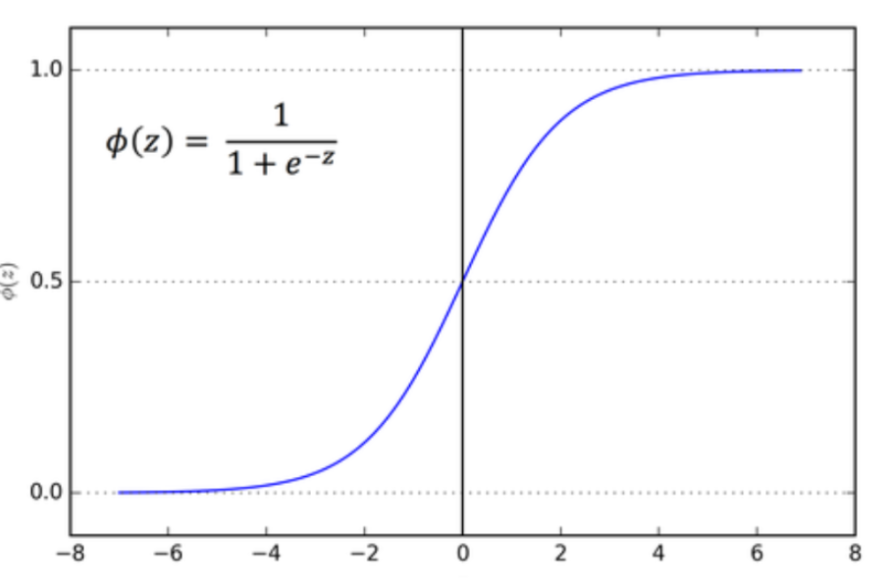

### Softmax 함수 : 다중분류에서 사용되는 함수
- 딥러닝 다중분류에서 출력층에서 사용되는 함수
- 각 정답의 종류에 따른 확률값을 출력하기 때문에 units의 수가 정답의 개수만큼 있어야 함
- 각 예측 확률의 합은 1로 설정한다.
- sigmoid에 비해 예측 오차 평균을 줄여주는 효과가 있기 때문에 다중분류에서 사용이 됨

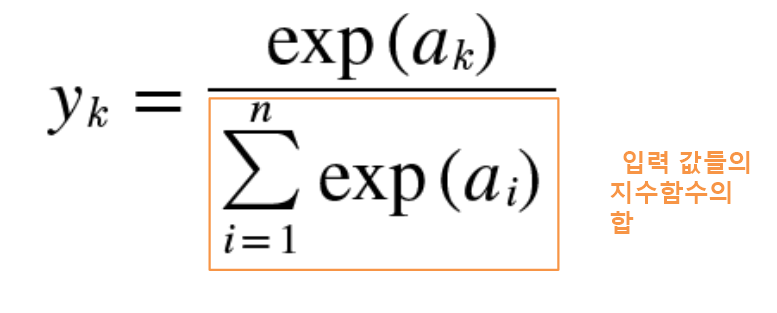